In [4]:
import pandas as pd

df = pd.read_csv("/content/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
df.shape

(1338, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [8]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


**First Visualization (Start Real Analytics)**

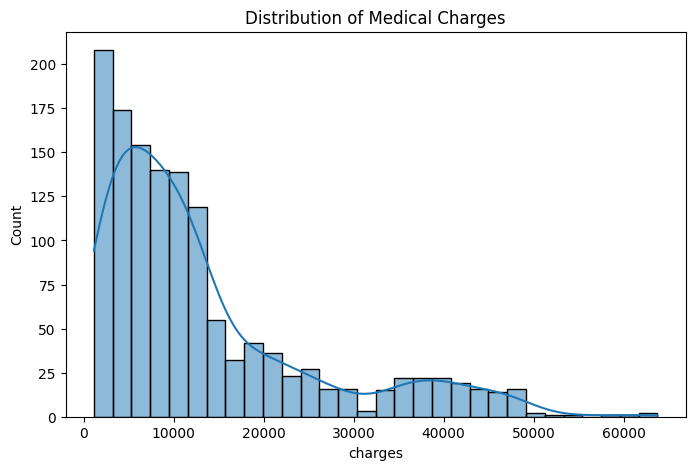

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df['charges'], kde=True)
plt.title("Distribution of Medical Charges")
plt.show()

**Smoking vs Medical Cost**

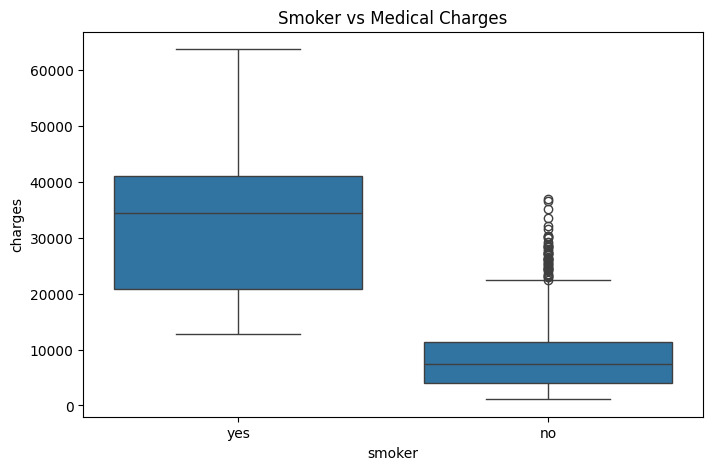

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Medical Charges")
plt.show()


**What you will observe ?**

Smokers have MUCH higher medical costs

This is strongest feature in dataset

**Business Insight**

Insurance companies must charge higher premiums for smokers.

**Age vs Cost Analysis**

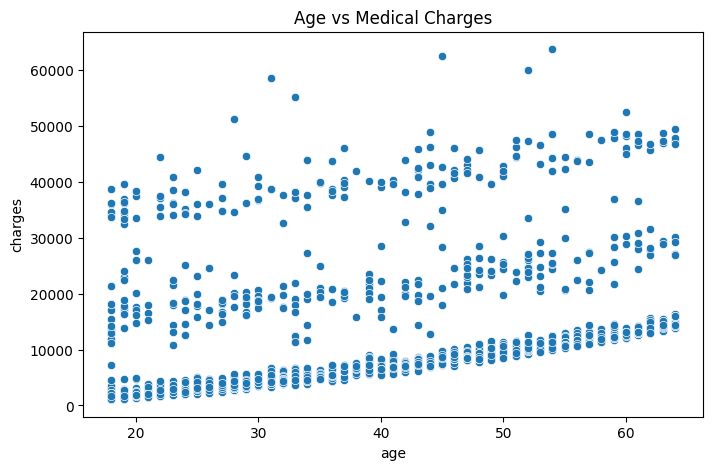

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Medical Charges")
plt.show()

**Insight**

Cost increases with age

Older patients = higher risk

**BMI vs Cost (Health Risk Insight)**

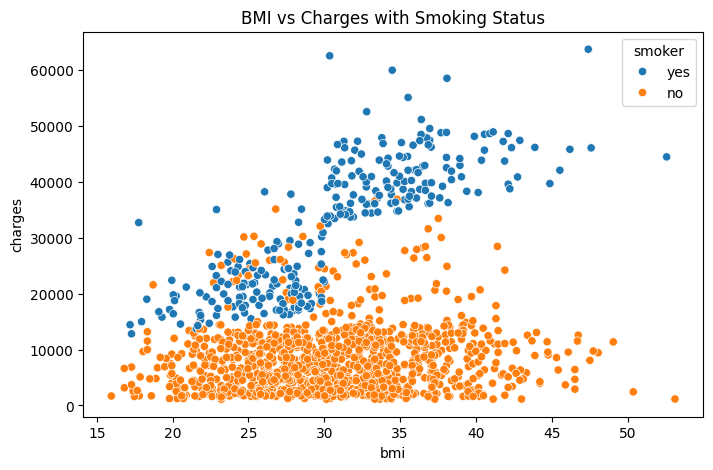

In [12]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title("BMI vs Charges with Smoking Status")
plt.show()

**Insight**

High BMI + Smoking = very high cost

Obesity risk visible

This is strong healthcare analytics insight.

**Region Analysis**

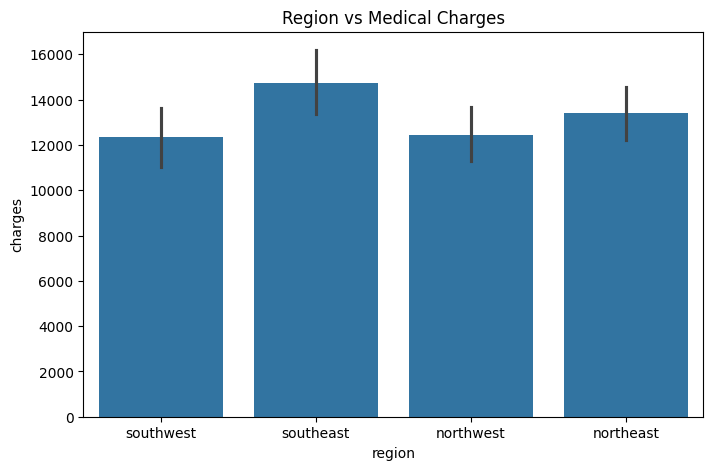

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='region', y='charges', data=df)
plt.title("Region vs Medical Charges")
plt.show()

**Insight**

Regional cost variation exists

Useful for pricing strategy

**BMI Category**

In [14]:
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df['bmi_category'] = df['bmi'].apply(bmi_category)

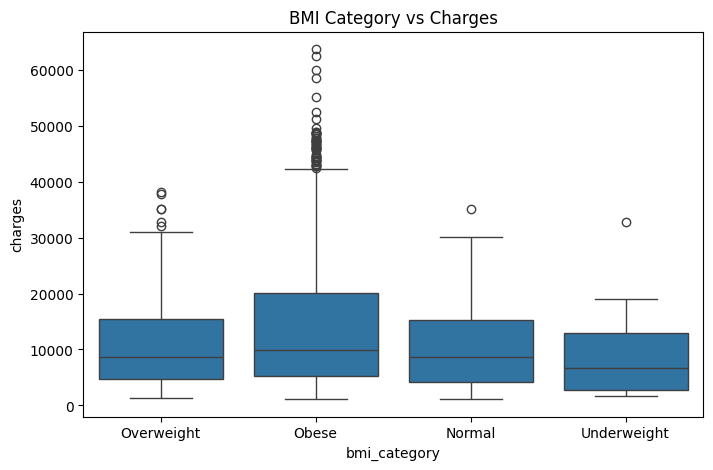

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bmi_category', y='charges', data=df)
plt.title("BMI Category vs Charges")
plt.show()

This is consulting-level analysis.

**Correlation Heatmap**

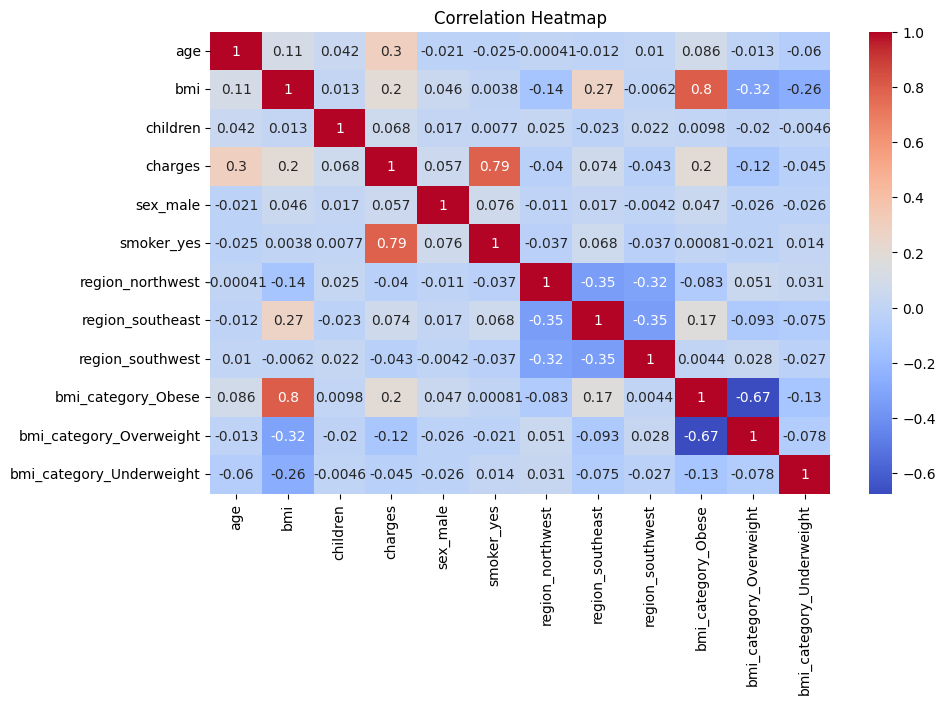

In [16]:
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(10,6))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()